# GeneFlow AI: clasificación taxonómica jerárquica de secuencias de ADN

Este notebook es el cuaderno de trabajo del TFM. Aquí se explora el dataset y, más adelante, se entrenan y evalúan los modelos. **La lógica reutilizable no vive aquí, sino en el paquete `taxonomy_classifier`**, que tiene tests, tipado estricto y un 90 % de cobertura mínima. El notebook solo lo importa y lo usa.

## Requisitos previos

Desde la raíz del repositorio:

| Paso | Comando | Qué hace |
|---|---|---|
| 1 | `uv sync` | Instala el paquete en modo editable junto con los grupos `dev` y `notebooks` |
| 2 | `uv run geneflow prepare` | Descarga las cuatro fuentes (~470 MB), construye el dataset y genera los datos sintéticos (~3 min) |
| 3 | `uv run jupyter lab` | Abre Jupyter. En PyCharm o VS Code, selecciona `.venv` como intérprete |

## De dónde salen los datos

Todas las fuentes contienen el gen del ARN ribosomal de la subunidad pequeña (16S en procariotas, 18S en eucariotas). **GTDB y PR2 son la taxonomía de referencia**: el resto de fuentes se traduce a ellas.

| Fuente | Aporta | Cómo se etiqueta |
|---|---|---|
| **GTDB r232** | 16S de bacterias y arqueas extraídos de genomas completos | Etiqueta propia, hasta especie |
| **PR2 5.1.1** | 18S nuclear de eucariotas, curado a mano | Etiqueta propia, hasta especie. Supergrupo y subdivisión quedan solo en el linaje original |
| **RefSeq 16S** | 16S de cepas tipo | Se traduce a GTDB por especie o, si no existe, por género |
| **SILVA 144 NR99** | Diversidad ambiental de los tres dominios | Se traduce por el nombre más profundo que exista sin ambigüedad en GTDB o PR2. La especie se recupera del nombre de organismo solo si llegó a género, es una especie con nombre formal, existe en GTDB o PR2 y su linaje coincide exactamente |

## Cómo se construye

1. **Lectura y filtrado.** Se descartan las secuencias de menos de 900 pb o de más de 4000 pb, las que tienen más de un 1 % de bases ambiguas, los orgánulos y los registros que no son del gen buscado.
2. **Eliminación de duplicados.** Las secuencias idénticas se fusionan. Si llegan con etiquetas distintas, se quedan con su ancestro común más profundo y se marcan con `label_conflict`. Si ni siquiera coincide el dominio, la secuencia se descarta.
3. **División determinista**, con una semilla fija:

| `split` | Contenido |
|---|---|
| `train` | ~90 % de las secuencias |
| `val`, `test` | ~5 % cada uno, elegidos al azar por secuencia |
| `test_novel_genus` | Todas las secuencias de ~5 % de los géneros, que el modelo nunca ve al entrenar. Mide si sabe generalizar hasta familia ante un género nuevo |

`build_report.json` detalla, para cada fuente, cuántas secuencias se leyeron, cuántas se descartaron y por qué, y hasta qué rango se etiquetaron. También recoge las estadísticas de la fusión y la configuración usada.

## Equilibrado con datos sintéticos

`geneflow augment` genera variantes sintéticas **solo de `train`** para los géneros con pocas secuencias. Validación y test son siempre 100 % reales.

| Regla | Valor |
|---|---|
| Qué se equilibra | Clases de género. Las secuencias sin género se agrupan por su rango más profundo, y cada clase pertenece a un solo reino |
| Suelo | 20 secuencias por clase |
| Copias por secuencia real | Como máximo 5, para que el modelo no memorice una sola secuencia |
| Proporción sintética | **Nunca más sintéticas que reales, dentro de cada reino.** Si un reino se pasa, sus copias se reducen proporcionalmente |
| Cómo se genera cada copia | 0,5 % de sustituciones, 0,1 % de inserciones y 0,1 % de deleciones (~99,4 % de identidad con el original). Es reproducible |
| Colisiones | Se descarta cualquier copia idéntica a una secuencia real de cualquier partición |

El resultado se guarda en `train_synthetic.parquet`, con las columnas `parent_seq_hash` (la secuencia de origen) y `synthetic`. `augment_report.json` recoge cuántas copias hay por reino y cuántas clases siguen por debajo del suelo.

Además, durante el entrenamiento `taxonomy_classifier.training` aplica al vuelo:
- **`SequenceAugmenter`:** recortes aleatorios que simulan lecturas cortas;
- **`balanced_weights`:** pesos de muestreo para el desequilibrio restante.

## Qué hace la celda de configuración

| Variable | Contenido |
|---|---|
| `PROJECT_ROOT` | La raíz del repositorio, detectada buscando `pyproject.toml`. El notebook funciona desde cualquier directorio |
| `LAYOUT` | Las rutas de datos: `LAYOUT.raw_dir(fuente)`, `LAYOUT.interim_dir`, `LAYOUT.processed_dir` |
| `DATASET_PATH`, `REPORT_PATH` | El Parquet final y su informe |
| `AUGMENT_REPORT_PATH` | El informe del equilibrado |
| `SYNTHETIC_PATH` | Las variantes sintéticas de `train` |
| `FIGURES_DIR` | `reports/figures/`: figuras exportadas para la memoria (se crea si no existe) |
| `SOURCES` | Las fuentes de datos, indexadas por su nombre corto (`gtdb_r232`, `pr2_5.1.1`…) |
| `RANK_COLUMNS` | Las columnas taxonómicas en orden jerárquico |
| `SPLITS` | Los nombres de las cuatro particiones |
| `KINGDOMS` | Los seis reinos clásicos |

Además limita el uso de la GPU al 90 % de su memoria (`GPU_MEMORY_FRACTION`), para que un exceso dé un error claro en lugar de desbordar a la RAM, y configura el `logging`, cómo muestra Polars las tablas y el estilo de Matplotlib (figuras a 300 ppp). Si el dataset o los datos sintéticos no existen, la celda se detiene con el comando que hay que ejecutar. No carga ningún dato: de eso se encarga la celda de carga.

**Salida.** Muestra dos tablas para comprobar de un vistazo que todo está en su sitio:
- **Los artefactos generados:** dataset, datos sintéticos e informes, con su tamaño y fecha de modificación.
- **Las fuentes:** si están descargadas, cuánto ocupan y si su hash está fijado (RefSeq no lo tiene, porque NCBI lo regenera a diario).

Además define la paleta de las gráficas (`SERIES`, `SURFACE`, `INK`…). Es la paleta de referencia validada para daltonismo, y los colores se asignan siempre en el mismo orden.

## Estructura del dataset

| Columna | Tipo | Descripción |
|---|---|---|
| `seq_hash` | binario | Huella BLAKE2b de 16 bytes de la secuencia. Identifica cada fila |
| `sequence` | texto | Secuencia de ADN normalizada (`U` pasa a `T`, en mayúsculas) |
| `length`, `n_ambiguous` | entero | Longitud y número de bases distintas de `A`, `C`, `G` y `T` |
| `domain` … `species` | texto o nulo | Un rango por columna. Nulo si se desconoce, es de relleno o hubo conflicto entre fuentes |
| `kingdom` | texto o nulo | Reino clásico: `Bacteria`, `Archaea`, `Animalia`, `Fungi`, `Plantae` o `Protista`. Nulo si no se puede determinar o las fuentes discrepan |
| `sources` | lista de texto | Fuentes que aportaron la secuencia (`gtdb`, `pr2`, `refseq`, `silva`) |
| `accessions` | lista de texto | Identificadores originales, como `fuente:accesión` |
| `n_records` | entero | Cuántos registros se fusionaron en esta fila |
| `label_conflict` | booleano | Las fuentes discrepaban y la etiqueta se recortó a su ancestro común |
| `split` | texto | `train`, `val`, `test` o `test_novel_genus` |

**Cómo se asigna `kingdom`:**
- **GTDB y RefSeq** usan el dominio.
- **PR2** usa su linaje original: la subdivisión Metazoa es `Animalia`, la subdivisión Fungi es `Fungi`, las divisiones Streptophyta, Chlorophyta, Prasinodermophyta, Rhodophyta y Glaucophyta son `Plantae` (Archaeplastida fotosintéticas, algas rojas incluidas) y el resto es `Protista`.
- **SILVA**: en procariotas usa el dominio. En eucariotas hereda el reino de su traducción a PR2, solo si no es ambiguo.

`Protista` no es un grupo natural: reúne todos los eucariotas que no son animales, plantas ni hongos.

En eucariotas, las columnas siguen la jerarquía de PR2. Por ejemplo, en un hongo `phylum` = Opisthokonta y `class` = Ascomycota. Es coherente dentro de PR2, pero no coincide con la nomenclatura clásica.


In [1]:
from dataclasses import asdict
from datetime import datetime
import json
import logging
import time
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import optuna
from optuna.importance import get_param_importances
import polars as pl
import torch
from tqdm import tqdm

from taxonomy_classifier.data.build import DataLayout
from taxonomy_classifier.data.columns import RANK_COLUMNS
from taxonomy_classifier.data.kingdom import Kingdom
from taxonomy_classifier.data.sources.registry import DEFAULT_SOURCES
from taxonomy_classifier.data.split import Split
from taxonomy_classifier.model.classifier import build_classifier, parameter_counts
from taxonomy_classifier.model.encoders import CnnConfig, TransformerConfig
from taxonomy_classifier.model.heads import HeadConfig
from taxonomy_classifier.model.labels import LEVELS, LabelSpace
from taxonomy_classifier.model.tokens import collate
from taxonomy_classifier.training.data import LabeledSet, TrainingData, class_frequencies
from taxonomy_classifier.training.oversampling import training_frame
from taxonomy_classifier.training.search import SearchConfig, objective_value, run_search, trial_rows
from taxonomy_classifier.training.trainer import EpochRecord, TrainingConfig, train_classifier

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists()
)

LAYOUT = DataLayout(root=PROJECT_ROOT / "data")
DATASET_PATH = LAYOUT.dataset_path
REPORT_PATH = LAYOUT.report_path
AUGMENT_REPORT_PATH = LAYOUT.augment_report_path
SYNTHETIC_PATH = LAYOUT.synthetic_path
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
LABEL_SPACE_PATH = LAYOUT.processed_dir / "label_space.json"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU_MEMORY_FRACTION = 0.9

if DEVICE.type == "cuda":
    torch.cuda.set_per_process_memory_fraction(GPU_MEMORY_FRACTION, DEVICE)

SOURCES = {source.slug: source for source in DEFAULT_SOURCES}
SPLITS = [split.value for split in Split]
KINGDOMS = [kingdom.value for kingdom in Kingdom]

if not DATASET_PATH.exists() or not SYNTHETIC_PATH.exists():
    msg = f"{DATASET_PATH} not found; run 'uv run geneflow prepare' from {PROJECT_ROOT}"
    raise FileNotFoundError(msg)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
)

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_thousands_separator(".")
pl.Config.set_decimal_separator(",")

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 110,
        "figure.facecolor": SURFACE,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": SURFACE,
        "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
        "text.color": INK,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.titlelocation": "left",
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.prop_cycle": plt.cycler(color=SERIES),
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_SECONDARY,
        "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False,
    }
)


def size(file: Path) -> str:
    size_bytes = file.stat().st_size

    if size_bytes >= 1e6:
        return f"{size_bytes / 1e6:.1f} MB".replace(".", ",")

    return f"{size_bytes / 1e3:.1f} kB".replace(".", ",")


artifacts = pl.DataFrame(
    [
        {
            "artefacto": name,
            "ruta": str(file.relative_to(PROJECT_ROOT)),
            "tamaño": size(file),
            "modificado": datetime.fromtimestamp(file.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
        }
        for name, file in {
            "dataset": DATASET_PATH,
            "sintéticos": SYNTHETIC_PATH,
            "informe build": REPORT_PATH,
            "informe augment": AUGMENT_REPORT_PATH,
        }.items()
    ]
)

sources = pl.DataFrame(
    [
        {
            "fuente": slug,
            "archivos": len(source.files),
            "descargado": all((LAYOUT.raw_dir(source) / remote.filename).exists() for remote in source.files),
            "tamaño": ", ".join(size(LAYOUT.raw_dir(source) / remote.filename) for remote in source.files),
            "hash fijado": all(remote.pinned for remote in source.files),
        }
        for slug, source in SOURCES.items()
    ]
)

display(artifacts, sources)

C:\develop\geneflow-ai-taxonomy-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


artefacto,ruta,tamaño,modificado
str,str,str,str
"""dataset""","""data\processed\geneflow\dataset.parquet""","""394,9 MB""","""2026-09-22 23:47"""
"""sintéticos""","""data\processed\geneflow\train_synthetic.parquet""","""110,4 MB""","""2026-09-22 23:48"""
"""informe build""","""data\processed\geneflow\build_report.json""","""3,1 kB""","""2026-09-22 23:47"""
"""informe augment""","""data\processed\geneflow\augment_report.json""","""1,1 kB""","""2026-09-22 23:48"""


fuente,archivos,descargado,tamaño,hash fijado
str,i64,bool,str,bool
"""gtdb_r232""",1,true,"""79,8 MB""",true
"""pr2_5.1.1""",1,true,"""59,6 MB""",true
"""refseq_16s""",2,true,"""8,0 MB, 300,8 kB""",false
"""silva_144""",1,true,"""324,2 MB""",true


## Carga de datos

Esta celda abre los datos, comprueba que están al día y muestra un resumen. **No carga las secuencias en memoria:** todo son `LazyFrame` de Polars, que solo leen del disco lo necesario cuando se llama a `.collect()`.

| Variable | Contenido |
|---|---|
| `dataset` | Todas las secuencias reales, de las cuatro particiones |
| `synthetic` | Las variantes sintéticas de `train`, con `parent_seq_hash` (la secuencia de origen) y `synthetic` |
| `splits` | Diccionario con cada partición real: `splits["val"]`, `splits["test"]`, `splits["test_novel_genus"]`… |
| `train` | `train` real más sintético, que es lo que verá el modelo. La columna `synthetic` distingue unas de otras |
| `build_report`, `augment_report` | Los informes de construcción y de equilibrado, como diccionarios |
| `overview` | Tabla resumen por partición: secuencias, cuántas son sintéticas y qué porcentaje tiene género y especie |

**Salida.** La celda muestra `overview` y una figura con tres paneles, que también se guarda en `reports/figures/dataset_overview.png`:
1. **Secuencias por partición**, separando reales y sintéticas;
2. **`train` por reino**, con el porcentaje de secuencias sintéticas de cada uno. Ningún reino puede pasar del 50 %, porque nunca hay más sintéticas que reales;
3. **Porcentaje de secuencias reales etiquetadas en cada rango**, de dominio a especie.

**Comprobaciones.** La celda se detiene si encuentra una de estas dos situaciones:
- **Los datos no coinciden con sus informes:** el número de secuencias reales o sintéticas del disco no es el que registraron `build` y `augment`.
- **Los datos sintéticos son anteriores al dataset:** se reconstruyó el dataset pero no se volvió a ejecutar `augment`, así que las copias podrían heredar etiquetas antiguas.

En los dos casos, la solución es `uv run geneflow prepare`.


split,sequences,synthetic,% genus,% species
enum,u32,u32,f64,f64
"""train""",1.405.999,294.384,"73,4","43,2"
"""val""",62.244,0,"67,0","32,3"
"""test""",62.517,0,"66,8","32,0"
"""test_novel_genus""",32.621,0,"100,0","58,0"


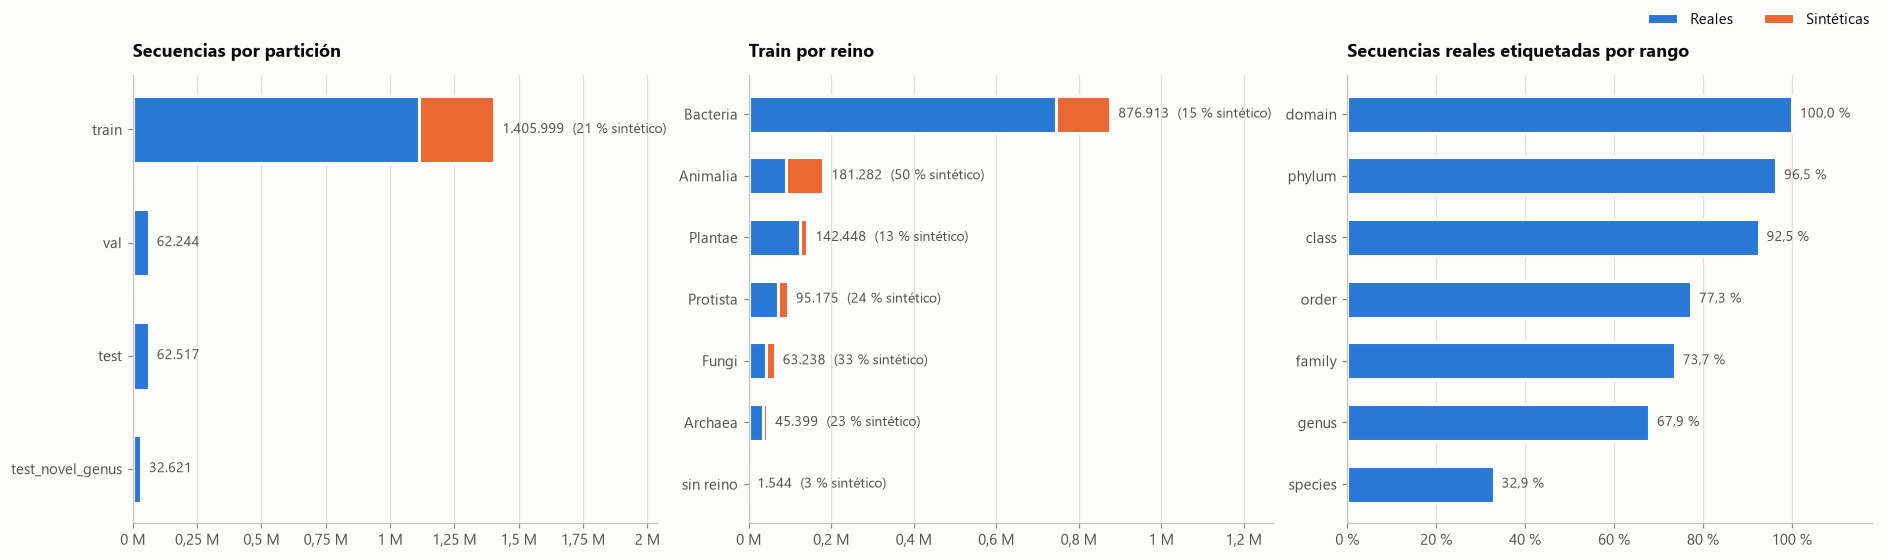

In [2]:
dataset = pl.scan_parquet(DATASET_PATH)
synthetic = pl.scan_parquet(SYNTHETIC_PATH)

build_report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
augment_report = json.loads(AUGMENT_REPORT_PATH.read_text(encoding="utf-8"))

if SYNTHETIC_PATH.stat().st_mtime < DATASET_PATH.stat().st_mtime:
    msg = "Synthetic data is older than the dataset; run 'uv run geneflow augment'"
    raise RuntimeError(msg)

expected = {"real": build_report["merge"]["kept"], "synthetic": augment_report["synthetic"]}
found = {
    "real": dataset.select(pl.len()).collect().item(),
    "synthetic": synthetic.select(pl.len()).collect().item(),
}

if found != expected:
    msg = f"Data on disk {found} does not match its reports {expected}; run 'uv run geneflow prepare'"
    raise RuntimeError(msg)

splits = {split: dataset.filter(pl.col("split") == split) for split in SPLITS}
train = training_frame(DATASET_PATH, SYNTHETIC_PATH)

records = pl.concat(
    [
        dataset.with_columns(pl.lit(value=False).alias("synthetic")),
        synthetic.drop("parent_seq_hash"),
    ],
    how="vertical",
)

overview = (
    records.group_by("split")
    .agg(
        pl.len().alias("sequences"),
        pl.col("synthetic").sum().alias("synthetic"),
        pl.col("genus").is_not_null().mean().mul(100).round(1).alias("% genus"),
        pl.col("species").is_not_null().mean().mul(100).round(1).alias("% species"),
    )
    .with_columns(pl.col("split").cast(pl.Enum(SPLITS)))
    .sort("split")
    .collect()
)

display(overview)


def thousands(value: int) -> str:
    return f"{value:,}".replace(",", ".")


def stacked_bars(axis: plt.Axes, frame: pl.DataFrame, label: str, title: str) -> None:
    labels = frame.get_column(label).to_list()
    real = frame.get_column("real").to_list()
    fake = frame.get_column("synthetic").to_list()

    axis.barh(labels, real, height=0.6, color=SERIES[0], edgecolor=SURFACE, linewidth=2, label="Reales")
    axis.barh(labels, fake, left=real, height=0.6, color=SERIES[1], edgecolor=SURFACE, linewidth=2, label="Sintéticas")

    for position, (count, extra) in enumerate(zip(real, fake, strict=True)):
        note = f"  {thousands(count + extra)}"

        if extra:
            note += f"  ({extra / (count + extra):.0%} sintético)".replace("%", " %")

        axis.text(count + extra, position, note, va="center", fontsize=9, color=INK_SECONDARY)

    axis.set_title(title)
    axis.grid(axis="y", visible=False)
    axis.xaxis.set_major_formatter(lambda value, _: f"{value / 1e6:g} M".replace(".", ","))
    axis.set_xlim(0, max(r + s for r, s in zip(real, fake, strict=True)) * 1.45)


split_counts = (
    overview.select(pl.col("split").cast(pl.String), (pl.col("sequences") - pl.col("synthetic")).alias("real"), "synthetic")
    .reverse()
)

kingdom_counts = (
    train.group_by(pl.col("kingdom").fill_null("sin reino"))
    .agg((~pl.col("synthetic")).sum().alias("real"), pl.col("synthetic").sum().alias("synthetic"))
    .sort(pl.col("real") + pl.col("synthetic"))
    .collect()
)

coverage = dataset.select(pl.col(RANK_COLUMNS).is_not_null().mean().mul(100)).collect().row(0)

figure, (splits_axis, kingdoms_axis, coverage_axis) = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")

stacked_bars(splits_axis, split_counts, "split", "Secuencias por partición")
stacked_bars(kingdoms_axis, kingdom_counts, "kingdom", "Train por reino")

coverage_axis.barh(RANK_COLUMNS[::-1], coverage[::-1], height=0.6, color=SERIES[0], edgecolor=SURFACE, linewidth=2)

for position, value in enumerate(coverage[::-1]):
    coverage_axis.text(value, position, f"  {value:.1f} %".replace(".", ","), va="center", fontsize=9, color=INK_SECONDARY)

coverage_axis.set_title("Secuencias reales etiquetadas por rango")
coverage_axis.set_xlim(0, 118)
coverage_axis.xaxis.set_major_formatter(lambda value, _: f"{value:.0f} %")
coverage_axis.grid(axis="y", visible=False)

figure.legend(*splits_axis.get_legend_handles_labels(), loc="outside upper right", ncols=2)

figure.savefig(FIGURES_DIR / "dataset_overview.png")
plt.show()

## Arquitectura

Comparamos **dos formas de leer la secuencia** con todo lo demás idéntico: las mismas etiquetas, las mismas cabezas de salida, la misma pérdida y la misma predicción. Así, cualquier diferencia de resultados se debe al encoder. Los dos encoders tienen además un número de parámetros parecido (~5 M), para que ninguno gane solo por ser más grande.

```
                    secuencia de ADN (A C G T N, hasta ~1.500 pb)
                                    │
                         embedding por base (64)
                    ┌───────────────┴───────────────┐
             B · CNN residual                C · Transformer
      bloques convolucionales con         una convolución (k=8, paso 4)
      dilataciones, reduce ×8 en 4 etapas   agrupa las bases en ~375 tokens de k-mers
      (128→192→256→320 canales)           6 capas de atención (8 cabezas, 256 dim)
      media + máximo → proyección a 256   con posición rotatoria (RoPE)
                    │                     media de tokens → 256
                    └───────────────┬───────────────┘
                          vector de 256 dimensiones
                                    │
              cabezas encadenadas: dominio → reino → filo → clase
                     → orden → familia → género → especie
         (cada nivel recibe la distribución predicha del nivel superior)
```

| Pieza | Decisión | Por qué |
|---|---|---|
| **Etiquetas** (`LabelSpace`) | Cada nivel aprende las clases con **≥3 secuencias reales en `train`**: ~13,6 mil géneros y ~20 mil especies | Son las clases que el equilibrado puede llevar a 18-20 ejemplos. Cubre el 95 % del género y el 65 % de la especie en `test`. Las clases más raras no se predicen, pero sus secuencias siguen entrenando los niveles superiores |
| **Relleno** | Máscaras en todas las operaciones | Una secuencia da la misma salida sola que en un lote (lo verifican los tests) |
| **Cabezas encadenadas** | El nivel *n* ve la distribución predicha en *n−1* | Favorece predicciones coherentes: el género se decide sabiendo la familia |
| **Pérdida** | Entropía cruzada por nivel, ignorando las etiquetas ausentes, y media de los niveles etiquetados | Una secuencia etiquetada solo hasta familia sigue aportando |
| **Predicción** (`predict`) | Se baja nivel a nivel y el modelo se abstiene cuando la confianza cae por debajo de un umbral | Devuelve "familia X, género incierto" en vez de inventarse un género |

**Salida de la celda:**
- una tabla con las clases de cada nivel y otra con los parámetros y la velocidad de cada modelo;
- una figura con ambas, que se guarda en `reports/figures/architectures.png`;
- una prueba de humo: un lote real de validación pasa por los dos modelos en la GPU y se comprueba que cada nivel devuelve el número de clases esperado.

El espacio de etiquetas se guarda en `data/processed/geneflow/label_space.json`, para que el entrenamiento y la evaluación usen exactamente las mismas clases.


nivel,clases
str,i64
"""domain""",3
"""kingdom""",6
"""phylum""",166
"""class""",579
"""order""",1.564
"""family""",3.623
"""genus""",13.558
"""species""",20.299


modelo,parámetros encoder,parámetros heads,parámetros total,ms por lote de 64,salidas correctas
str,i64,i64,i64,f64,bool
"""CNN""",5.137.408,14.022.902,19.160.310,"20,8",true
"""Transformer""",4.870.784,14.022.902,18.893.686,"34,8",true


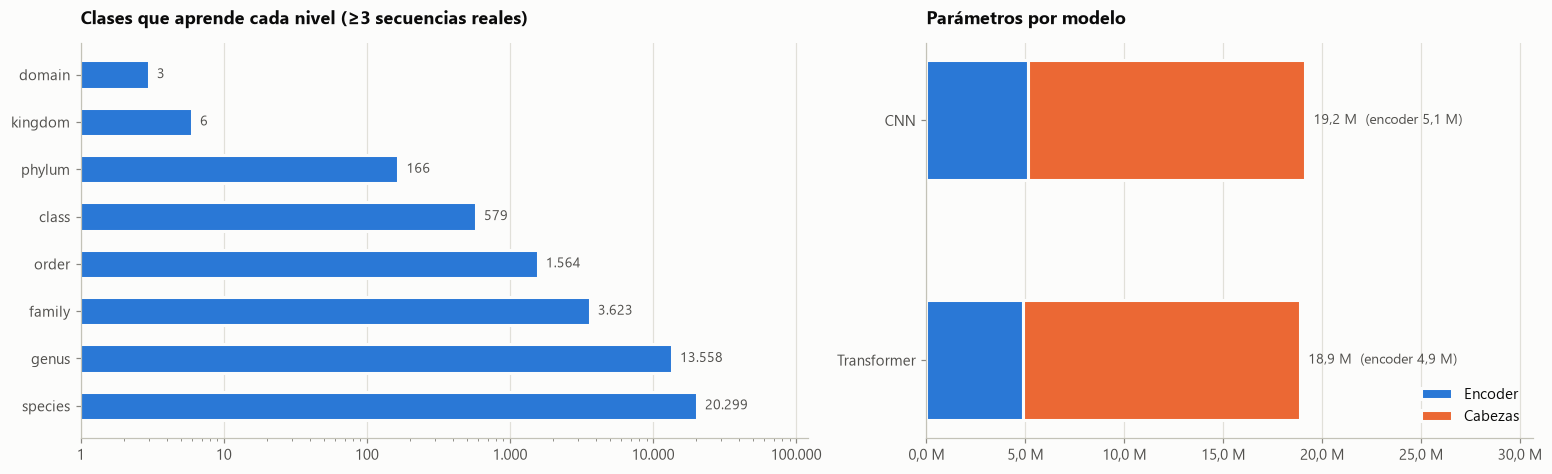

In [3]:
MIN_CLASS_COUNT = 3

ARCHITECTURES = {
    "CNN": CnnConfig(),
    "Transformer": TransformerConfig(),
}

HEADS = HeadConfig()

label_space = LabelSpace.from_frame(train.filter(~pl.col("synthetic")), min_count=MIN_CLASS_COUNT)
LABEL_SPACE_PATH.write_text(label_space.to_json(), encoding="utf-8")

models = {
    name: build_classifier(encoder, label_space, HEADS).to(DEVICE)
    for name, encoder in ARCHITECTURES.items()
}

sample = splits["val"].select("sequence").head(64).collect().get_column("sequence").to_list()
tokens, mask = collate(sample)
tokens, mask = tokens.to(DEVICE), mask.to(DEVICE)


def milliseconds_per_batch(model: torch.nn.Module, repeats: int = 10) -> float:
    model.eval()

    with torch.inference_mode():
        model(tokens, mask)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(repeats):
            model(tokens, mask)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

    return 1000 * (time.perf_counter() - start) / repeats


def outputs_match_label_space(model: torch.nn.Module) -> bool:
    with torch.inference_mode():
        logits = model.eval()(tokens, mask)

    return [tuple(level.shape) for level in logits] == [(len(sample), size) for size in label_space.sizes]


levels = pl.DataFrame({"nivel": LEVELS, "clases": label_space.sizes})

architectures = pl.DataFrame(
    [
        {
            "modelo": name,
            **{f"parámetros {part}": count for part, count in parameter_counts(model).items()},
            f"ms por lote de {len(sample)}": round(milliseconds_per_batch(model), 1),
            "salidas correctas": outputs_match_label_space(model),
        }
        for name, model in models.items()
    ]
)

display(levels, architectures)


def millions(value: float) -> str:
    return f"{value / 1e6:.1f} M".replace(".", ",")


figure, (levels_axis, parameters_axis) = plt.subplots(
    1, 2, figsize=(14, 4.2), layout="constrained", gridspec_kw={"width_ratios": [1.2, 1]}
)

levels_axis.barh(LEVELS[::-1], label_space.sizes[::-1], height=0.6, color=SERIES[0], edgecolor=SURFACE, linewidth=2)

for position, size in enumerate(label_space.sizes[::-1]):
    levels_axis.text(size, position, f"  {size:,}".replace(",", "."), va="center", fontsize=9, color=INK_SECONDARY)

levels_axis.set_xscale("log")
levels_axis.xaxis.set_major_formatter(lambda value, _: f"{value:,.0f}".replace(",", "."))
levels_axis.set_xlim(1, max(label_space.sizes) * 6)
levels_axis.set_title(f"Clases que aprende cada nivel (≥{MIN_CLASS_COUNT} secuencias reales)")
levels_axis.grid(axis="y", visible=False)

names = list(models)[::-1]
encoders = architectures.get_column("parámetros encoder").to_list()[::-1]
heads = architectures.get_column("parámetros heads").to_list()[::-1]

parameters_axis.barh(names, encoders, height=0.5, color=SERIES[0], edgecolor=SURFACE, linewidth=2, label="Encoder")
parameters_axis.barh(names, heads, left=encoders, height=0.5, color=SERIES[1], edgecolor=SURFACE, linewidth=2, label="Cabezas")

for position, (encoder, head) in enumerate(zip(encoders, heads, strict=True)):
    parameters_axis.text(
        encoder + head,
        position,
        f"  {millions(encoder + head)}  (encoder {millions(encoder)})",
        va="center",
        fontsize=9,
        color=INK_SECONDARY,
    )

parameters_axis.set_title("Parámetros por modelo")
parameters_axis.set_xlim(0, max(e + h for e, h in zip(encoders, heads, strict=True)) * 1.6)
parameters_axis.xaxis.set_major_formatter(lambda value, _: millions(value))
parameters_axis.grid(axis="y", visible=False)
parameters_axis.legend(loc="lower right")

figure.savefig(FIGURES_DIR / "architectures.png")
plt.show()

## Datos de entrenamiento

Prepara los datos que usan el entrenamiento de prueba y la búsqueda de hiperparámetros. Se ejecuta una sola vez por sesión.

| Variable | Contenido |
|---|---|
| `train_set` | Las ~1,4 M secuencias de `train` (reales y sintéticas) codificadas, junto con sus etiquetas |
| `val_set` | Las ~62 mil secuencias reales de `val` |
| `training_data` | Las dos anteriores, más la **frecuencia del género de cada secuencia**. Cada entrenamiento calcula a partir de ella sus pesos de muestreo con su propio `sampling_power`, así que la búsqueda puede probar distintos grados de equilibrado |

La primera vez, las secuencias se codifican en `data/interim/geneflow/*_tokens.bin` (~2 GB). Se leen proyectadas desde el disco, sin ocupar RAM, y las ejecuciones siguientes las cargan en segundos. Si cambia el dataset, la caché se regenera sola.


In [4]:
train_set = LabeledSet.from_frame(train, label_space, cache=LAYOUT.interim_dir / "train_tokens.bin")
val_set = LabeledSet.from_frame(splits["val"], label_space, cache=LAYOUT.interim_dir / "val_tokens.bin")

training_data = TrainingData(
    train=train_set,
    frequencies=class_frequencies(train),
    validation=val_set,
)

print(f"train: {len(train_set):,} secuencias | val: {len(val_set):,} | dispositivo: {DEVICE}".replace(",", "."))

train: 1.405.999 secuencias | val: 62.244 | dispositivo: cuda


## Entrenamiento de prueba (CNN)

Un entrenamiento corto para comprobar que todo funciona de principio a fin antes de lanzar los entrenamientos largos. **3 épocas de 150.000 secuencias cada una**, muestreadas de `train` (real y sintético) con los pesos de equilibrado. Una época completa tendría 1,4 millones.

| Parámetro | Valor | Por qué |
|---|---|---|
| Optimizador | AdamW, tasa 3·10⁻⁴, *weight decay* 0,05 | Estándar para redes profundas; el *weight decay* no se aplica a normalizaciones ni sesgos |
| Tasa de aprendizaje | Calentamiento lineal durante el 5 % de los pasos y después descenso en coseno hasta 0 | Evita inestabilidades al principio y afina al final |
| Lote | 128 secuencias | Cabe con margen en los 16 GB de la GPU |
| Precisión | Mixta, `bfloat16` | Casi el doble de rápido en la RTX 4080 y sin pérdida de calidad apreciable |
| Muestreo | Con reemplazo, peso ∝ 1/√(secuencias del género) | Completa el equilibrado de los datos sintéticos sin repetir en exceso los géneros raros |
| Recortes | El 50 % de las secuencias se recorta al azar a 150-500 pb | Enseña al modelo a clasificar también lecturas cortas |
| Validación | Toda `val` (62 mil secuencias reales), al final de cada época | Mide la precisión por nivel sobre datos que el modelo no ha visto |

**Progreso en vivo:**
- una barra por época con los lotes procesados, la pérdida media, las secuencias por segundo, la tasa de aprendizaje y el tiempo restante;
- una barra para la validación;
- al terminar cada época, una línea de resumen y una tabla con el historial, que se va actualizando;
- al final, una figura con la evolución de la pérdida y la precisión por nivel, que se guarda en `reports/figures/cnn_trial.png`.

**Qué se guarda en `checkpoints/cnn-trial/`:**
- `last.pt`: los pesos de la última época;
- `best.pt`: los pesos de la época con menor pérdida de validación;
- `history.json`: el historial.

Necesita haber ejecutado antes la celda **Datos de entrenamiento**.


train: 1.405.999 secuencias | val: 62.244 | dispositivo: cuda


época,pérdida train,pérdida val,% domain,% kingdom,% phylum,% class,% order,% family,% genus,% species,minutos
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"4,278","2,795","99,8","97,3","87,2","76,9","50,1","28,4","24,3","7,8","4,7"
2,"3,0888","2,04","99,9","98,2","94,8","89,6","76,4","54,2","37,7","12,5","6,1"
3,"2,7316","1,9124","99,9","98,4","95,6","91,1","79,0","60,7","39,9","15,9","6,5"


  validación: 100%|████████████████████████████████████████████████████████████████▋| 243/244 [02:17<00:00,  3.75lote/s]2026-09-23 00:48:28,875 INFO     taxonomy_classifier.training.trainer: Epoch 1/3: train 4.2780, val 2.7950, genus 0.243, 284 s
                                                                                                                        

Época 1: pérdida 4.278 → val 2.795 | género 24.3 % | especie 7.8 % | 4.7 min


  validación: 100%|████████████████████████████████████████████████████████████████▋| 243/244 [02:19<00:00,  3.54lote/s]2026-09-23 00:54:36,828 INFO     taxonomy_classifier.training.trainer: Epoch 2/3: train 3.0888, val 2.0400, genus 0.377, 367 s
                                                                                                                        

Época 2: pérdida 3.089 → val 2.040 | género 37.7 % | especie 12.5 % | 6.1 min


  validación:  99%|████████████████████████████████████████████████████████████████▍| 242/244 [02:30<00:00,  3.00lote/s]2026-09-23 01:01:07,984 INFO     taxonomy_classifier.training.trainer: Epoch 3/3: train 2.7316, val 1.9124, genus 0.399, 391 s
                                                                                                                        

Época 3: pérdida 2.732 → val 1.912 | género 39.9 % | especie 15.9 % | 6.5 min


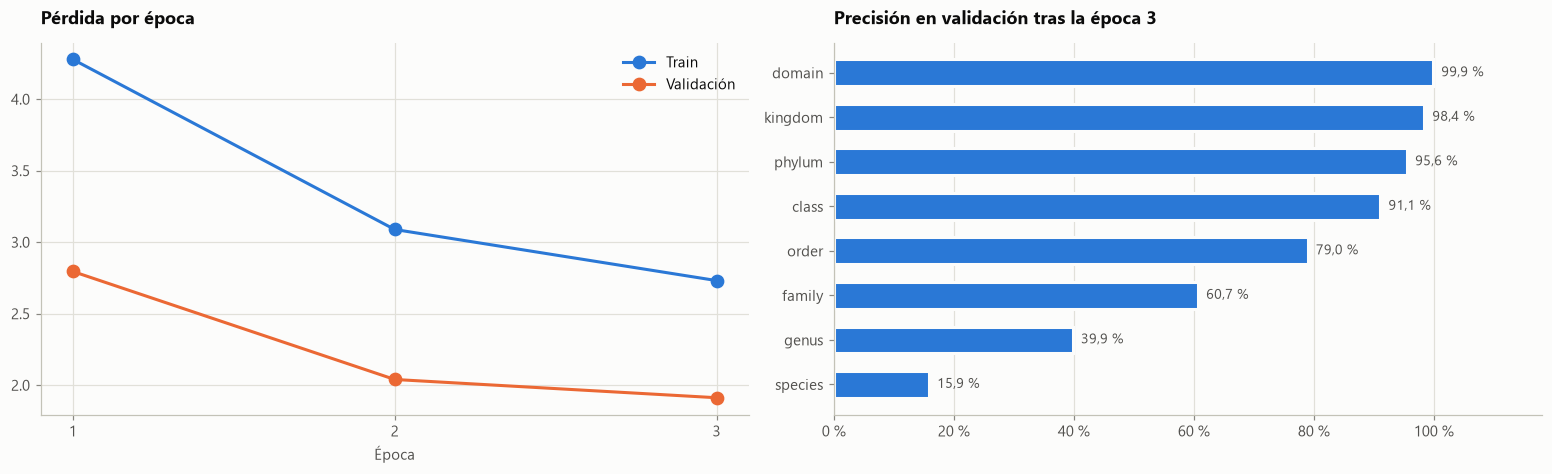

In [6]:
TRIAL_NAME = "cnn-trial"
TRIAL_ARCHITECTURE = "CNN"

TRIAL = TrainingConfig(epochs=3, samples_per_epoch=150_000, batch_size=128, log_every=25)


class NotebookMonitor:
    def __init__(self) -> None:
        self.bar: tqdm | None = None
        self.rows: list[dict[str, object]] = []
        self.table = display(pl.DataFrame({"época": []}), display_id=True)

    def epoch_started(self, epoch: int, epochs: int, steps: int) -> None:
        self.bar = tqdm(total=steps, desc=f"Época {epoch}/{epochs}", unit="lote", ncols=120, mininterval=0.5)

    def step_finished(self, step: int) -> None:
        self.bar.update(1)

    def metrics_updated(self, step: int, loss: float, sequences_per_second: float, learning_rate: float) -> None:
        self.bar.set_postfix(pérdida=f"{loss:.3f}", seq_s=f"{sequences_per_second:,.0f}", lr=f"{learning_rate:.1e}")

    def evaluation_started(self, batches: int) -> None:
        self.bar.close()
        self.bar = tqdm(total=batches, desc="  validación", unit="lote", ncols=120, mininterval=0.5, leave=False)

    def evaluation_step(self) -> None:
        self.bar.update(1)

    def epoch_finished(self, record: EpochRecord) -> None:
        self.bar.close()

        accuracy = {level: round(100 * value, 1) for level, value in record.validation.accuracy.items()}

        self.rows.append(
            {
                "época": record.epoch,
                "pérdida train": round(record.train_loss, 4),
                "pérdida val": round(record.validation.loss, 4),
                **{f"% {level}": value for level, value in accuracy.items()},
                "minutos": round(record.seconds / 60, 1),
            }
        )

        tqdm.write(
            f"Época {record.epoch}: pérdida {record.train_loss:.3f} → val {record.validation.loss:.3f} | "
            f"género {accuracy['genus']} % | especie {accuracy['species']} % | {record.seconds / 60:.1f} min"
        )

        self.table.update(pl.DataFrame(self.rows))


torch.manual_seed(TRIAL.seed)
trial_model = build_classifier(ARCHITECTURES[TRIAL_ARCHITECTURE], label_space, HEADS)

trial_history = train_classifier(
    trial_model,
    training_data,
    config=TRIAL,
    checkpoint_dir=CHECKPOINTS_DIR / TRIAL_NAME,
    device=DEVICE,
    metadata={"architecture": TRIAL_ARCHITECTURE, "encoder": asdict(ARCHITECTURES[TRIAL_ARCHITECTURE])},
    monitor=NotebookMonitor(),
)

epochs = [record.epoch for record in trial_history]
final_accuracy = trial_history[-1].validation.accuracy

figure, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(14, 4.2), layout="constrained")

loss_axis.plot(epochs, [record.train_loss for record in trial_history], marker="o", linewidth=2, markersize=8, color=SERIES[0], label="Train")
loss_axis.plot(epochs, [record.validation.loss for record in trial_history], marker="o", linewidth=2, markersize=8, color=SERIES[1], label="Validación")
loss_axis.set_title("Pérdida por época")
loss_axis.set_xticks(epochs)
loss_axis.set_xlabel("Época")
loss_axis.legend()

accuracy_axis.barh(LEVELS[::-1], [100 * final_accuracy[level] for level in LEVELS[::-1]], height=0.6, color=SERIES[0], edgecolor=SURFACE, linewidth=2)

for position, level in enumerate(LEVELS[::-1]):
    accuracy_axis.text(100 * final_accuracy[level], position, f"  {100 * final_accuracy[level]:.1f} %".replace(".", ","), va="center", fontsize=9, color=INK_SECONDARY)

accuracy_axis.set_xlim(0, 118)
accuracy_axis.xaxis.set_major_formatter(lambda value, _: f"{value:.0f} %")
accuracy_axis.set_title(f"Precisión en validación tras la época {epochs[-1]}")
accuracy_axis.grid(axis="y", visible=False)

figure.savefig(FIGURES_DIR / "cnn_trial.png")
plt.show()

## Búsqueda de hiperparámetros (Optuna)

Busca la mejor configuración de cada arquitectura **con el mismo presupuesto para las dos**, para que la comparación final sea justa.

**Qué se busca:**

| Común a las dos | Solo CNN | Solo Transformer |
|---|---|---|
| Tasa de aprendizaje (10⁻⁴-3·10⁻³, escala logarítmica), *weight decay* (10⁻³-0,2), calentamiento (2-10 %), dropout (0-0,3), exponente de muestreo (0-1), probabilidad de recorte (0,2-0,8) | Anchura de capas (`small`, `base`, `large`), bloques por etapa (2 o 3), tamaño del filtro (5-11) | Capas (4, 6 u 8), dimensión (192, 256 o 320), tokenizador de k-mers (6/3, 8/4 o 12/6) |

**Cómo funciona:**
- **Muestreo TPE:** las primeras 5 pruebas exploran al azar. Después, Optuna propone valores cerca de los que mejor han funcionado.
- **Cada prueba es un entrenamiento corto** de 3 épocas de 100 mil secuencias. Tarda unos 12 minutos, y no guarda checkpoints.
- **Parada temprana:** a partir de la sexta prueba, si al acabar una época su objetivo queda por debajo de la mediana de las anteriores en esa misma época, se corta. Así el presupuesto se gasta en las configuraciones prometedoras.
- **Objetivo:** la precisión media en `val` de género y especie. Está fijado de antemano. `test` y `test_novel_genus` no se tocan hasta la evaluación final.
- **Se puede reanudar:** cada estudio se guarda en `checkpoints/search/<arquitectura>.log`. Si interrumpes la celda y la vuelves a ejecutar, continúa donde lo dejó hasta completar `SEARCH.trials` pruebas.
- **Si una configuración no cabe en la GPU,** esa prueba se marca como fallida y la búsqueda sigue. Para que esto funcione, la celda de configuración limita el proceso al 90 % de la memoria de la GPU. Sin ese tope, el driver de NVIDIA en Windows desborda a la RAM del sistema en lugar de dar un error, y el entrenamiento se vuelve decenas de veces más lento.
- **Las secuencias se truncan a 2.048 pb** (`TrainingConfig.max_length`), lo que afecta al 0,65 %. Evita que las pocas secuencias eucariotas de hasta 4.000 pb disparen la memoria de un lote.

**Duración estimada:** unas 3-4 horas para la CNN y unas 6 para el Transformer. Para lanzar solo una, cambia `SEARCH_ARCHITECTURES`.

**Salida:**
- durante la búsqueda, una línea por prueba con sus hiperparámetros, barras de progreso por época y el objetivo alcanzado;
- al terminar cada arquitectura, sus 10 mejores pruebas;
- al final, una tabla con la mejor configuración de cada arquitectura y una figura, guardada en `reports/figures/search.png`, con la evolución de la búsqueda y la importancia de cada hiperparámetro.

Necesita haber ejecutado antes la celda **Datos de entrenamiento**.


In [ ]:
SEARCH = SearchConfig(trials=20, epochs=3, samples_per_epoch=100_000)
SEARCH_ARCHITECTURES = ["CNN", "Transformer"]
SEARCH_DIR = CHECKPOINTS_DIR / "search"

optuna.logging.set_verbosity(optuna.logging.WARNING)


def describe(value: object) -> str:
    return f"{value:.3g}" if isinstance(value, float) else str(value)


class TrialMonitor:
    def __init__(self, architecture: str, trial: optuna.Trial) -> None:
        self.bar: tqdm | None = None

        parameters = ", ".join(f"{name}={describe(value)}" for name, value in trial.params.items())
        tqdm.write(f"\n{architecture} · prueba {trial.number + 1}/{SEARCH.trials}: {parameters}")

    def epoch_started(self, epoch: int, epochs: int, steps: int) -> None:
        self.bar = tqdm(total=steps, desc=f"  época {epoch}/{epochs}", unit="lote", ncols=120, mininterval=0.5, leave=False)

    def step_finished(self, step: int) -> None:
        self.bar.update(1)

    def metrics_updated(self, step: int, loss: float, sequences_per_second: float, learning_rate: float) -> None:
        self.bar.set_postfix(pérdida=f"{loss:.3f}", seq_s=f"{sequences_per_second:,.0f}")

    def evaluation_started(self, batches: int) -> None:
        self.bar.close()
        self.bar = tqdm(total=batches, desc="  validación", unit="lote", ncols=120, mininterval=0.5, leave=False)

    def evaluation_step(self) -> None:
        self.bar.update(1)

    def epoch_finished(self, record: EpochRecord) -> None:
        self.bar.close()

        accuracy = record.validation.accuracy
        objective = objective_value(record.validation, SEARCH.objective_levels)

        tqdm.write(
            f"  época {record.epoch}: género {100 * accuracy['genus']:.1f} % | "
            f"especie {100 * accuracy['species']:.1f} % | objetivo {100 * objective:.1f} % | "
            f"{record.seconds / 60:.1f} min"
        )


def trial_table(study: optuna.Study) -> pl.DataFrame:
    return (
        pl.DataFrame(trial_rows(study), infer_schema_length=None)
        .with_columns((pl.col("value") * 100).round(2).alias("objetivo %"))
        .drop("value")
        .sort("objetivo %", descending=True, nulls_last=True)
    )


studies: dict[str, optuna.Study] = {}

for architecture in SEARCH_ARCHITECTURES:
    studies[architecture] = run_search(
        architecture,
        training_data,
        label_space,
        config=SEARCH,
        storage=SEARCH_DIR / f"{architecture.lower()}.log",
        device=DEVICE,
        monitor_factory=lambda trial, architecture=architecture: TrialMonitor(architecture, trial),
    )

    print(f"\n{architecture}: las 10 mejores pruebas")
    display(trial_table(studies[architecture]).head(10))


def completed(study: optuna.Study) -> list[optuna.trial.FrozenTrial]:
    return [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]


best = pl.DataFrame(
    [
        {
            "arquitectura": architecture,
            "pruebas": len(study.trials),
            "completas": len(completed(study)),
            "podadas": sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials),
            "mejor prueba": study.best_trial.number,
            "objetivo %": round(100 * study.best_value, 2),
            "hiperparámetros": ", ".join(f"{name}={describe(value)}" for name, value in study.best_params.items()),
        }
        for architecture, study in studies.items()
        if completed(study)
    ]
)

display(best)

figure, axes = plt.subplots(1, 1 + len(studies), figsize=(7 + 5 * len(studies), 4.2), layout="constrained")
history_axis, importance_axes = axes[0], axes[1:]

for color, (architecture, study) in zip(SERIES, studies.items()):
    finished = [trial for trial in study.trials if trial.intermediate_values]
    numbers = [trial.number + 1 for trial in finished]
    reached = [100 * (trial.value if trial.value is not None else trial.intermediate_values[max(trial.intermediate_values)]) for trial in finished]
    running_best = [max(reached[: index + 1]) for index in range(len(reached))]

    history_axis.scatter(numbers, reached, s=36, color=color, alpha=0.55, edgecolors=SURFACE, linewidths=1)
    history_axis.plot(numbers, running_best, linewidth=2, color=color, label=f"{architecture} (mejor hasta ahora)")

history_axis.set_title("Evolución de la búsqueda")
history_axis.set_xlabel("Prueba")
history_axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0f} %")
history_axis.legend()

for axis, (architecture, study) in zip(importance_axes, studies.items()):
    axis.set_title(f"Importancia de hiperparámetros · {architecture}")
    axis.grid(axis="y", visible=False)

    if len(completed(study)) < 2:
        axis.text(0.5, 0.5, "Hacen falta al menos 2 pruebas completas", ha="center", va="center", transform=axis.transAxes, color=INK_SECONDARY)
        continue

    importances = get_param_importances(study)
    names = list(importances)[::-1]
    values = [100 * importances[name] for name in names]

    axis.barh(names, values, height=0.6, color=SERIES[0], edgecolor=SURFACE, linewidth=2)

    for position, value in enumerate(values):
        axis.text(value, position, f"  {value:.0f} %", va="center", fontsize=9, color=INK_SECONDARY)

    axis.set_xlim(0, max(values) * 1.3)
    axis.xaxis.set_major_formatter(lambda value, _: f"{value:.0f} %")

figure.savefig(FIGURES_DIR / "search.png")
plt.show()


CNN · prueba 1/20: dropout=0.193, learning_rate=0.00061, weight_decay=0.0411, warmup_fraction=0.0812, sampling_power=0.505, crop_probability=0.627, cnn_width=large, cnn_blocks=two, cnn_kernel=7


  validación:  98%|███████████████████████████████████████████████████████████████▉ | 240/244 [00:47<00:00,  9.16lote/s]2026-09-23 17:25:35,353 INFO     taxonomy_classifier.training.trainer: Epoch 1/3: train 4.5490, val 3.4802, genus 0.172, 182 s


  época 1: género 17.2 % | especie 4.1 % | objetivo 10.6 % | 3.0 min


  validación:  98%|███████████████████████████████████████████████████████████████▉ | 240/244 [00:26<00:00,  9.32lote/s]2026-09-23 17:27:54,877 INFO     taxonomy_classifier.training.trainer: Epoch 2/3: train 3.6577, val 2.8163, genus 0.209, 140 s


  época 2: género 20.9 % | especie 5.3 % | objetivo 13.1 % | 2.3 min


...

  validación:  98%|███████████████████████████████████████████████████████████████▍ | 238/244 [00:17<00:00, 15.30lote/s]2026-09-23 17:34:44,708 INFO     taxonomy_classifier.training.trainer: Epoch 3/3: train 3.0081, val 2.9119, genus 0.130, 95 s


  época 3: género 13.0 % | especie 0.8 % | objetivo 6.9 % | 1.6 min

CNN · prueba 3/20: dropout=0.184, learning_rate=0.00177, weight_decay=0.191, warmup_fraction=0.0959, sampling_power=0.749, crop_probability=0.402, cnn_width=large, cnn_blocks=two, cnn_kernel=5


  validación: 100%|█████████████████████████████████████████████████████████████████| 244/244 [17:16<00:00,  3.48s/lote]2026-09-23 17:54:39,708 INFO     taxonomy_classifier.training.trainer: Epoch 1/3: train 4.6160, val 3.8841, genus 0.025, 1194 s


  época 1: género 2.5 % | especie 0.3 % | objetivo 1.4 % | 19.9 min


  época 2/3:  13%|████████▏                                                       | 100/782 [16:24<1:48:43,  9.56s/lote]